In [1]:
# install all libraries
!pip install hopsworks shap pandas numpy --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.5/771.5 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.6/258.6 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.9 MB/s eta 0:00:00
   

In [1]:
!pip install hopsworks==4.2.*


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 665.0/665.0 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 58.9 MB/s eta 0:00:00
  Created wheel for avro: filename=avro-1.11.3-py2.py3-none-any.whl size=123962 sha256=4c3808b12469988318e0f1dc88e56b4329fee9ec517c9ebad07113de072ec78e
  Stored in directory: /root/.cache/pip/wheels/3a/82/d3/8eb96fda033c7f1661086e2f8afb13f04817886d28b12f1e72
Successfully built avro
  Attempting uninstall: sqla

In [1]:
import hopsworks
import joblib
import shap
import matplotlib.pyplot as plt
import pandas as pd
import os
from google.colab import userdata
import seaborn as sns
import numpy as np

In [2]:
import hopsworks

project = hopsworks.login()
fs = project.get_feature_store()


Copy your Api Key (first register/login): https://c.app.hopsworks.ai/account/api/generated

Paste it here: ··········

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1335449


In [3]:
# Get your Feature Group
aqi_fg = fs.get_feature_group(name="islamabad_aqi_v12", version=5)

In [4]:
raw_df = aqi_fg.read()


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.61s) 


In [ ]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,5)

In [15]:
print("Data Preview (last rows):")
display(raw_df.tail(5))

Data Preview (last rows):


,datetime,city,aqi,pm2_5,no2,so2,temperature,humidity,wind_speed,hour,weekday,month,aqi_lag_1,pm2_5_rolling_6h,wind_stagnant
2965,2026-02-01 07:00:00+00:00,Islamabad,5.0,157.85,4.69,5.66,15.4,54.0,7.4,7.0,6.0,2.0,5.0,237.668333,0.0
2966,2026-02-01 08:00:00+00:00,Islamabad,5.0,114.61,2.50,4.19,16.0,52.0,9.3,8.0,6.0,2.0,5.0,227.121667,0.0
2967,2026-02-01 09:00:00+00:00,Islamabad,5.0,95.27,2.15,3.44,16.5,51.0,11.1,9.0,6.0,2.0,5.0,208.183333,0.0
2968,2026-02-01 10:00:00+00:00,Islamabad,5.0,89.72,3.34,2.92,16.1,52.0,11.1,10.0,6.0,2.0,5.0,184.538333,0.0
2969,2026-02-01 11:00:00+00:00,Islamabad,5.0,93.93,5.90,2.63,15.7,54.0,11.1,11.0,6.0,2.0,5.0,159.160000,0.0


In [ ]:
print("Data Preview (First 5 rows):")
display(raw_df.head())

Data Preview (First 5 rows):


,datetime,city,aqi,pm2_5,no2,so2,temperature,humidity,wind_speed,hour,weekday,month,aqi_lag_1,pm2_5_rolling_6h,wind_stagnant
0,2025-12-21 04:00:00+00:00,Islamabad,5.0,392.74,15.86,1.80,14.2,71.0,9.3,4.0,6.0,12.0,5.0,393.598333,0.0
1,2025-10-27 18:00:00+00:00,Islamabad,5.0,105.79,25.06,7.04,18.6,69.0,5.5,18.0,0.0,10.0,5.0,89.588333,0.0
2,2025-12-26 04:00:00+00:00,Islamabad,5.0,157.86,29.04,6.19,10.1,67.0,1.8,4.0,4.0,12.0,5.0,138.853333,1.0
3,2025-10-26 21:00:00+00:00,Islamabad,5.0,111.92,16.38,6.15,17.1,67.0,1.8,21.0,6.0,10.0,5.0,96.740000,1.0
4,2026-01-04 12:00:00+00:00,Islamabad,5.0,111.82,13.58,3.56,14.5,62.0,9.3,12.0,6.0,1.0,5.0,116.861667,0.0


In [16]:
cols_to_show = ['datetime', 'aqi', 'pm2_5', 'hour', 'weekday', 'aqi_lag_1']
print("Strategic Data Preview:")
display(raw_df[cols_to_show].tail(10))

Strategic Data Preview:


,datetime,aqi,pm2_5,hour,weekday,aqi_lag_1
2960,2026-02-01 00:00:00+00:00,5.0,217.15,0.0,6.0,5.0
2961,2026-02-01 04:00:00+00:00,5.0,241.99,4.0,6.0,5.0
2962,2026-02-01 03:00:00+00:00,5.0,237.14,3.0,6.0,5.0
2963,2026-02-01 05:00:00+00:00,5.0,245.25,5.0,6.0,5.0
2964,2026-02-01 06:00:00+00:00,5.0,252.26,6.0,6.0,5.0
2965,2026-02-01 07:00:00+00:00,5.0,157.85,7.0,6.0,5.0
2966,2026-02-01 08:00:00+00:00,5.0,114.61,8.0,6.0,5.0
2967,2026-02-01 09:00:00+00:00,5.0,95.27,9.0,6.0,5.0
2968,2026-02-01 10:00:00+00:00,5.0,89.72,10.0,6.0,5.0
2969,2026-02-01 11:00:00+00:00,5.0,93.93,11.0,6.0,5.0


In [17]:
# Quick check for total rows and data types
print("\nDataset Info:")
raw_df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2970 entries, 0 to 2969
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype                  
---  ------            --------------  -----                  
 0   datetime          2970 non-null   datetime64[us, Etc/UTC]
 1   city              2970 non-null   object                 
 2   aqi               2970 non-null   float64                
 3   pm2_5             2970 non-null   float64                
 4   no2               2970 non-null   float64                
 5   so2               2970 non-null   float64                
 6   temperature       2970 non-null   float64                
 7   humidity          2970 non-null   float64                
 8   wind_speed        2970 non-null   float64                
 9   hour              2970 non-null   float64                
 10  weekday           2970 non-null   float64                
 11  month             2970 non-null   float64             

In [ ]:
print("Null values per column:")
print(raw_df.isnull().sum())


Null values per column:
datetime            0
city                0
aqi                 0
pm2_5               0
no2                 0
so2                 0
temp                0
humidity            0
wind_speed          0
hour                0
weekday             0
month               0
aqi_lag_1           0
pm2_5_rolling_6h    0
wind_stagnant       0
dtype: int64


In [ ]:
raw_df.isnull().sum()


***EDA*** ***Graphs***

**Daily Average AQI Trend**

In [ ]:
import plotly.express as px

# --- 🟢 GRAPH 1: (Daily Average AQI) ---
df_daily = raw_df.resample('D', on='datetime').aqi.mean().reset_index()

fig1 = px.bar(df_daily, x='datetime', y='aqi',
             title='Islamabad Air Quality: Last Few Days',
             labels={'aqi': 'Pollution Level (1=Best, 5=Worst)', 'datetime': 'Date'},
             color='aqi',
             color_continuous_scale=['green', 'yellow', 'orange', 'red', 'purple'])
fig1.show()

**AQI Category Distribution**

In [ ]:
# --- 🔵 GRAPH 2: AQI Scoreboard (Pie Chart) ---
# Air Quality
status_map = {1: "Good (clean) ", 2: "Fair", 3: "Moderate", 4: "Poor", 5: "Very Poor (Dangerous)"}
raw_df['Condition'] = raw_df['aqi'].round().map(status_map)

fig2 = px.pie(raw_df, names='Condition',
             title='Overall Air Quality Distribution in Islamabad',
             color_discrete_map={'Good (clean)': 'green', 'Very Poor (Dangerous)': 'purple', 'Poor': 'red'})
fig2.show()

**Temperature vs AQI Relationship**

In [ ]:
# --- 🟡 GRAPH 3: (Temperature vs AQI) ---
# Is pollution increase in cold?
fig3 = px.box(raw_df, x='aqi', y='temperature',
             title='Relation between Cold Weather and Pollution',
             labels={'aqi': 'Pollution Level', 'temperature': 'Temperature (°C)'},
             color='aqi')
fig3.show()

**Weather Factors Impacting AQI**

/tmp/ipython-input-1062513653.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




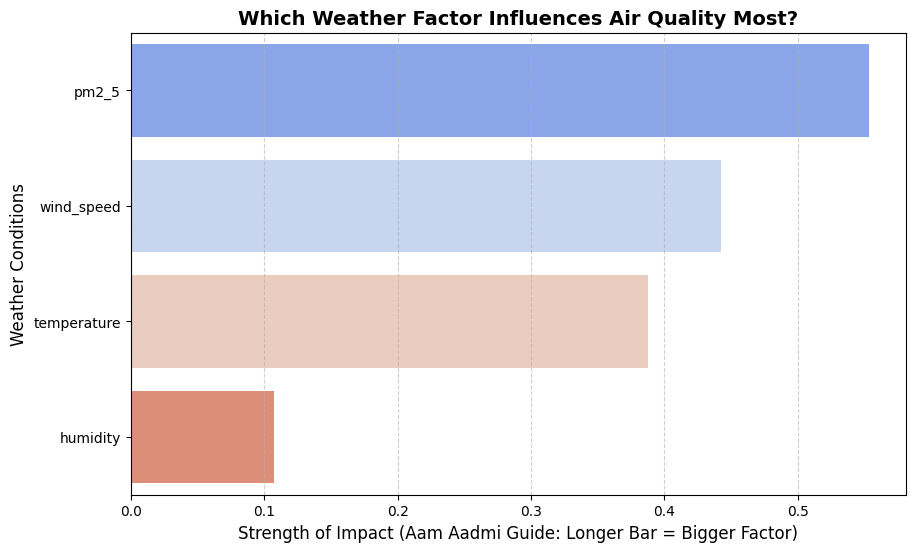

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. AQI ke saath baaqi cheezon ka talluq (Correlation) nikalna
# Hum sirf un columns ko le rahe hain jo layman samajh sakay
features = ['aqi', 'temperature', 'humidity', 'wind_speed', 'pm2_5']
corr_data = raw_df[features].corr()['aqi'].drop('aqi').reset_index()
corr_data.columns = ['Weather Factor', 'Impact_Score']

# Score ko absolute (positive) kar dete hain taake sirf taqat nazar aaye
corr_data['Impact_Score'] = corr_data['Impact_Score'].abs()
corr_data = corr_data.sort_values(by='Impact_Score', ascending=False)

# 2. Simple Bar Plot
plt.figure(figsize=(10, 6))
# 'Impact_Score' jitna zyada hoga, bar utni lambi hogi
sns.barplot(x='Impact_Score', y='Weather Factor', data=corr_data, palette='coolwarm')

plt.title('Which Weather Factor Influences Air Quality Most?', fontsize=14, fontweight='bold')
plt.xlabel('Strength of Impact (Aam Aadmi Guide: Longer Bar = Bigger Factor)', fontsize=12)
plt.ylabel('Weather Conditions', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

**Monthly Average AQI Trends**

In [ ]:
import plotly.express as px

# 1. Data ko pehle sort karein aur mahine ka naam nikalein
raw_df['datetime'] = pd.to_datetime(raw_df['datetime'])
df_sorted = raw_df.sort_values('datetime')
df_sorted['Month'] = df_sorted['datetime'].dt.strftime('%B %Y')

# 2. Monthly average nikalein
# Hum 'numeric_only=True' use kar rahe hain taake sirf numbers ka mean niklay
df_monthly = df_sorted.groupby('Month', sort=False)['aqi'].mean().reset_index()

# 3. Simple Bar Graph
fig = px.bar(df_monthly,
             x='Month',
             y='aqi',
             title='Islamabad: Average Pollution Level by Month',
             labels={'aqi': 'Average AQI (1-5)', 'Month': 'Month'},
             color='aqi',
             color_continuous_scale='RdYlGn_r', # Green to Red scale
             text_auto='.1f') # Bars ke upar value dikhanay ke liye

fig.update_layout(xaxis_tickangle=-45)
fig.show()

**Pollutant Contribution to AQI**

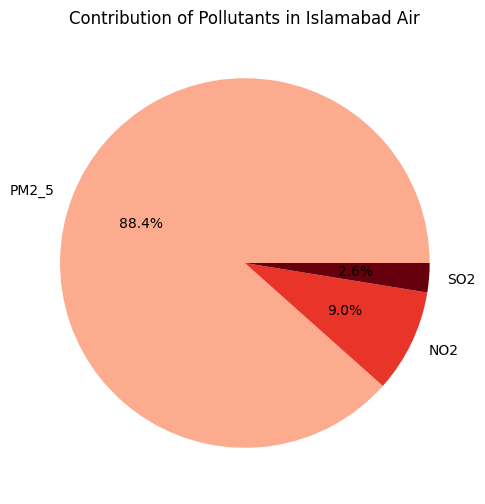

In [ ]:
pollutants = ['pm2_5', 'no2', 'so2']
avg_values = raw_df[pollutants].mean()

plt.figure(figsize=(6, 6))
plt.pie(avg_values, labels=[p.upper() for p in pollutants], autopct='%1.1f%%',
        colors=plt.cm.Reds(np.linspace(0.3, 1, len(pollutants))))
plt.title('Contribution of Pollutants in Islamabad Air')
plt.savefig('Contribution of Pollutants in Islamabad Air')
plt.show()

**Distribution of Key Pollutants**

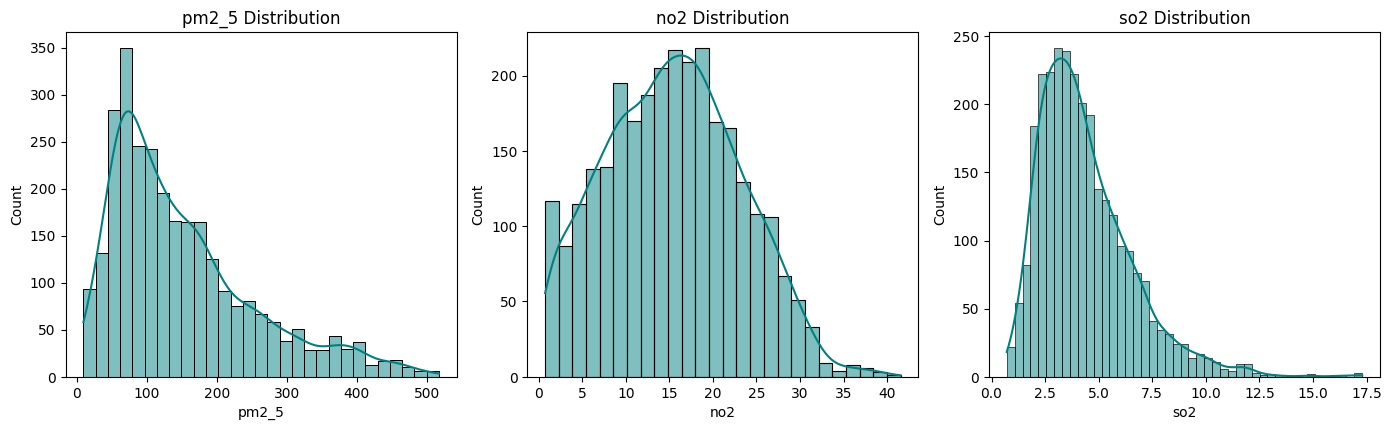

In [ ]:
# Pollutant Distribution (PM2.5, PM10, CO, etc.)

pollutants = ['pm2_5', 'no2', 'so2']

plt.figure(figsize=(14,8))
for i, col in enumerate(pollutants):
    plt.subplot(2, 3, i+1)
    sns.histplot(raw_df[col], kde=True, color='teal')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.savefig("Pollutants Distribution.png")
plt.show()

**Most Critical Pollutant Analysis**

Most critical pollutant in Islamabad: pm2_5 (Average concentration: 150.97)


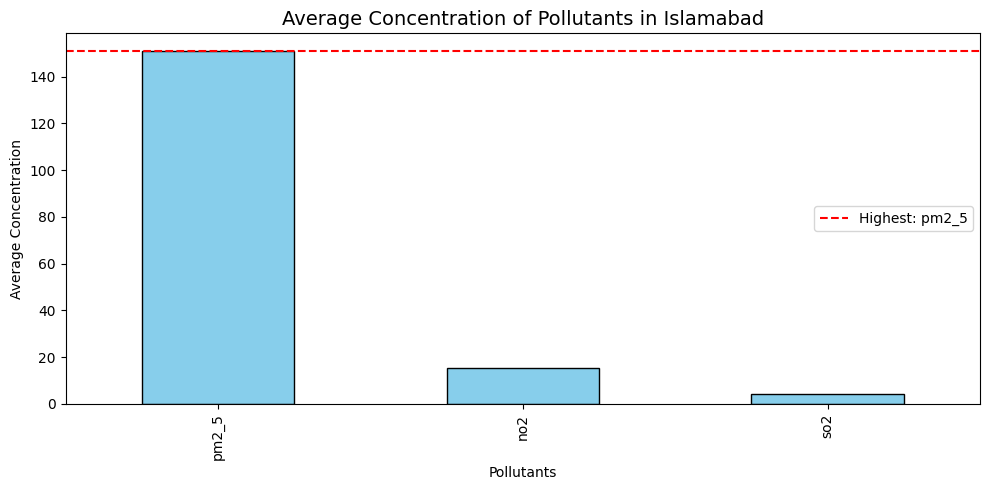

In [ ]:
# Define your pollutants
pollutants = ['pm2_5', 'no2', 'so2']

# Calculate average concentration of each pollutant
avg_concentrations = raw_df[pollutants].mean().sort_values(ascending=False)

# Identify the most critical one
most_critical = avg_concentrations.idxmax()
most_value = avg_concentrations.max()

# Print result
print('='*60)
print(f"Most critical pollutant in Islamabad: {most_critical} (Average concentration: {most_value:.2f})")
print('='*60)

# Plot
plt.figure(figsize=(10, 5))
avg_concentrations.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Concentration of Pollutants in Islamabad', fontsize=14)
plt.ylabel('Average Concentration')
plt.xlabel('Pollutants')
plt.axhline(y=most_value, color='red', linestyle='--', label=f'Highest: {most_critical}')
plt.legend()
plt.tight_layout()
plt.savefig('Average Concentration of Pollutants in Islamabad.png')
plt.show()

**Correlation Analysis of AQI and Features**


📊 POLLUTANT CORRELATION ANALYSIS

🔥 STRONGEST CORRELATIONS (|corr| > 0.7):
----------------------------------------
pm2_5 ↔ pm2_5_rolling_6h: 0.967
aqi ↔ aqi_lag_1: 0.952
temperature ↔ humidity: -0.703

🖼️ Displaying Correlation Heatmap...


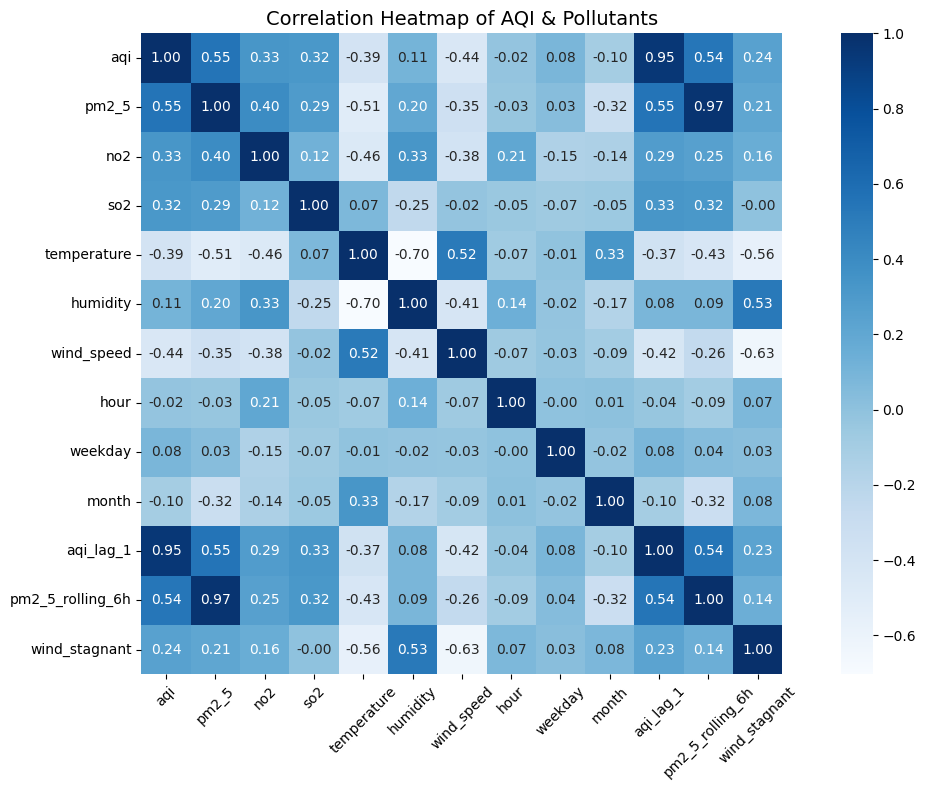


📈 Correlation of Features with AQI:
aqi                 1.000000
aqi_lag_1           0.952167
pm2_5               0.553317
pm2_5_rolling_6h    0.537691
no2                 0.333047
so2                 0.318288
wind_stagnant       0.242048
humidity            0.107636
weekday             0.082832
hour               -0.018024
month              -0.099265
temperature        -0.387629
wind_speed         -0.442380
Name: aqi, dtype: float64


/tmp/ipython-input-563425939.py:51: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.

/tmp/ipython-input-563425939.py:52: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.



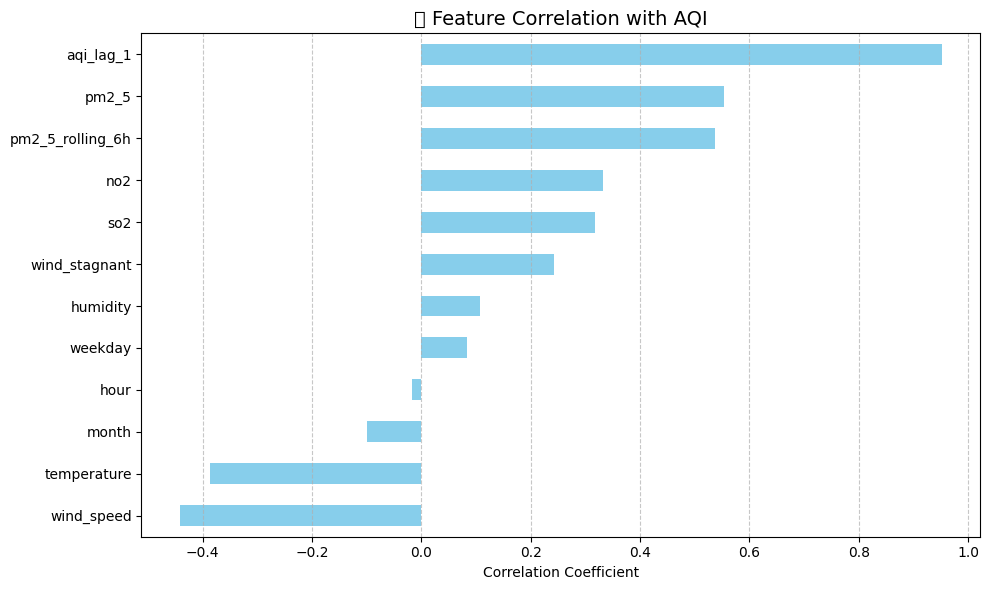

In [ ]:
import numpy as np
def correlation_analysis(df):
    """
    Perform correlation analysis between all features (including AQI),
    print strongest correlated pairs, show heatmap, and barplot of AQI correlations.
    """
    print("\n📊 POLLUTANT CORRELATION ANALYSIS")
    print("="*60)

    # Select only numeric columns for correlation analysis
    df_numeric = df.select_dtypes(include=np.number)

    # Compute correlation matrix
    corr = df_numeric.corr()

    # Print strongest correlation pairs
    print("\n🔥 STRONGEST CORRELATIONS (|corr| > 0.7):")
    print("-" * 40)
    strong = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            val = corr.iloc[i, j]
            if abs(val) > 0.7:
                strong.append((corr.index[i], corr.columns[j], val))
    for var1, var2, val in sorted(strong, key=lambda x: abs(x[2]), reverse=True):
        print(f"{var1} ↔ {var2}: {val:.3f}")

    # Heatmap
    print("\n🖼️ Displaying Correlation Heatmap...")
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f", square=True)
    plt.title("Correlation Heatmap of AQI & Pollutants", fontsize=14)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig("Correlation Heatmap of AQI & Pollutants.png")
    plt.show()

    # AQI Correlation Bar Plot
    if 'aqi' in corr.columns: # Changed 'AQI' to 'aqi'
        print("\n📈 Correlation of Features with AQI:")
        corr_with_aqi = corr['aqi'].sort_values(ascending=False) # Changed 'AQI' to 'aqi'
        print(corr_with_aqi)

        plt.figure(figsize=(10, 6))
        corr_with_aqi.drop('aqi').plot(kind='barh', color='skyblue') # Changed 'AQI' to 'aqi'
        plt.title('🔍 Feature Correlation with AQI', fontsize=14)
        plt.xlabel('Correlation Coefficient')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig("Feature Correlation with AQI.png")
        plt.show()
    else:
        print("⚠️ 'aqi' column not found in the dataset.")

# Call the function with raw_df
correlation_analysis(raw_df)

***SHAP Analysis***

Connection closed.

Logged in to project, explore it here https://c.app.hopsworks.ai:443/p/1335449


Downloading: 0.000%|          | 0/161881 elapsed<00:00 remaining<?

✅ Best model loaded: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (0.52s) 


✅ Features ready: ['temperature', 'humidity', 'wind_speed', 'hour', 'weekday', 'month', 'aqi_lag_1', 'pm2_5_rolling_6h', 'wind_stagnant']


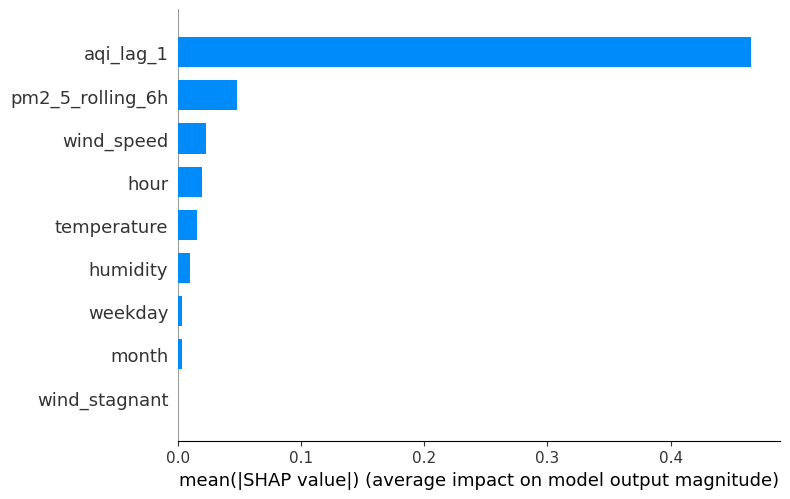

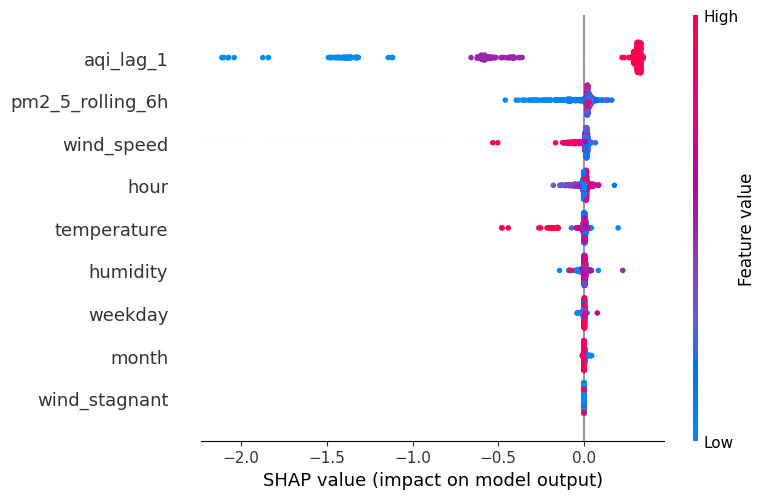

<Figure size 640x480 with 0 Axes>

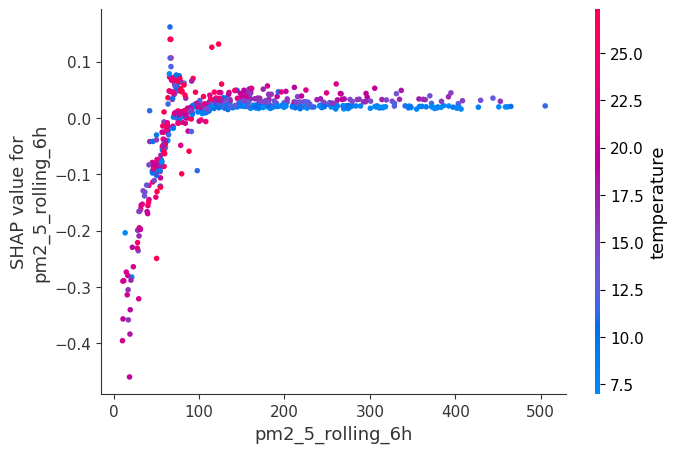

✅ SHAP analysis completed successfully in Colab!


<Figure size 640x480 with 0 Axes>

In [14]:
# 🔹 Colab-friendly SHAP Analysis for AQI Model

import hopsworks
import joblib
import shap
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv # Added for environment variables

load_dotenv() # Load environment variables


# --- 1️⃣ Initialize Hopsworks Connection ---
# Ensure project, fs, mr are available
project = hopsworks.login(api_key_value=os.getenv("HOPSWORKS_KEY")) # Login to Hopsworks
fs = project.get_feature_store() # Get feature store
mr = project.get_model_registry() # Get model registry


# --- 2️⃣ Download & load best model ---
best_model_registry = mr.get_model("best_islamabad_aqi_model")
model_dir = best_model_registry.download() # 'model_dir' will now hold the path to the downloaded directory

# Find the actual .pkl file within the downloaded directory
model_files = [f for f in os.listdir(model_dir) if f.endswith('.pkl')]
if not model_files:
    raise FileNotFoundError(f"No .pkl model file found in the downloaded directory: {model_dir}")
model_filename = model_files[0]
model_path = os.path.join(model_dir, model_filename) # Correctly construct the path to the model file

best_model = joblib.load(model_path)
print("✅ Best model loaded:", best_model)


# --- 3️⃣ Fetch test features from Feature View ---
fv = fs.get_feature_view(name="islamabad_aqi_viewss", version=1)
X_train, X_test, y_train, y_test = fv.train_test_split(test_size=0.2)

# --- 4️⃣ Clean features for SHAP ---
cols_to_drop = ['aqi', 'pm2_5', 'city', 'datetime', 'timestamp', 'no2', 'so2']

def clean_features(df):
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    return df.select_dtypes(include=['number']).fillna(0)

X_test = clean_features(X_test)
print(f"✅ Features ready: {list(X_test.columns)}")

# --- 5️⃣ Initialize SHAP Explainer ---
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# --- 6️⃣ Global Feature Importance (Bar Plot) ---
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)
plt.savefig("shap_summary_bar.png", dpi=300)

# --- 7️⃣ Detailed Summary Plot (Impact of feature values) ---
shap.summary_plot(shap_values, X_test, show=True)
plt.savefig("shap_summary_detailed.png", dpi=300)

# --- 8️⃣ Dependence Plot for a Key Feature ---
shap.dependence_plot("pm2_5_rolling_6h", shap_values, X_test)
plt.savefig("shap_dependence_pm2_5.png", dpi=300)

# --- 9️⃣ Force Plot for a Single Prediction (local explanation) ---
shap.initjs()  # Works in Colab for interactive JS plots
sample = X_test.iloc[0,:]
shap.force_plot(explainer.expected_value, shap_values[0,:], sample)
# Force plot will show inline in Colab

print("✅ SHAP analysis completed successfully in Colab!")